In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
from skimage.metrics import mean_squared_error, peak_signal_noise_ratio, structural_similarity

In [2]:
def bilateral_filter_scratch(src, d, sigma_color, sigma_space):
    radius = d // 2
    h, w = src.shape
    src = src.astype(np.float32)

    # Create Gaussian spatial kernel
    x, y = np.meshgrid(np.arange(-radius, radius+1), np.arange(-radius, radius+1))
    spatial_kernel = np.exp(-(x**2 + y**2) / (2 * sigma_space**2))

    dst = np.zeros_like(src)

    for i in range(h):
        for j in range(w):
            # Define the neighborhood boundaries
            i_min = max(i - radius, 0)
            i_max = min(i + radius + 1, h)
            j_min = max(j - radius, 0)
            j_max = min(j + radius + 1, w)

            # Extract the local region
            region = src[i_min:i_max, j_min:j_max]

            # Compute the Gaussian range kernel
            intensity_diff = region - src[i, j]
            range_kernel = np.exp(-(intensity_diff**2) / (2 * sigma_color**2))

            # Combine the spatial and range kernels
            combined_kernel = spatial_kernel[(i_min - i + radius):(i_max - i + radius),
                                             (j_min - j + radius):(j_max - j + radius)] * range_kernel

            # Normalize weights
            norm_factor = np.sum(combined_kernel)
            if norm_factor == 0:
                norm_factor = 1

            # Compute the filtered pixel value
            dst[i, j] = np.sum(region * combined_kernel) / norm_factor

    return dst.astype(src.dtype)


Height: 500, Width: 500, Channels: 1


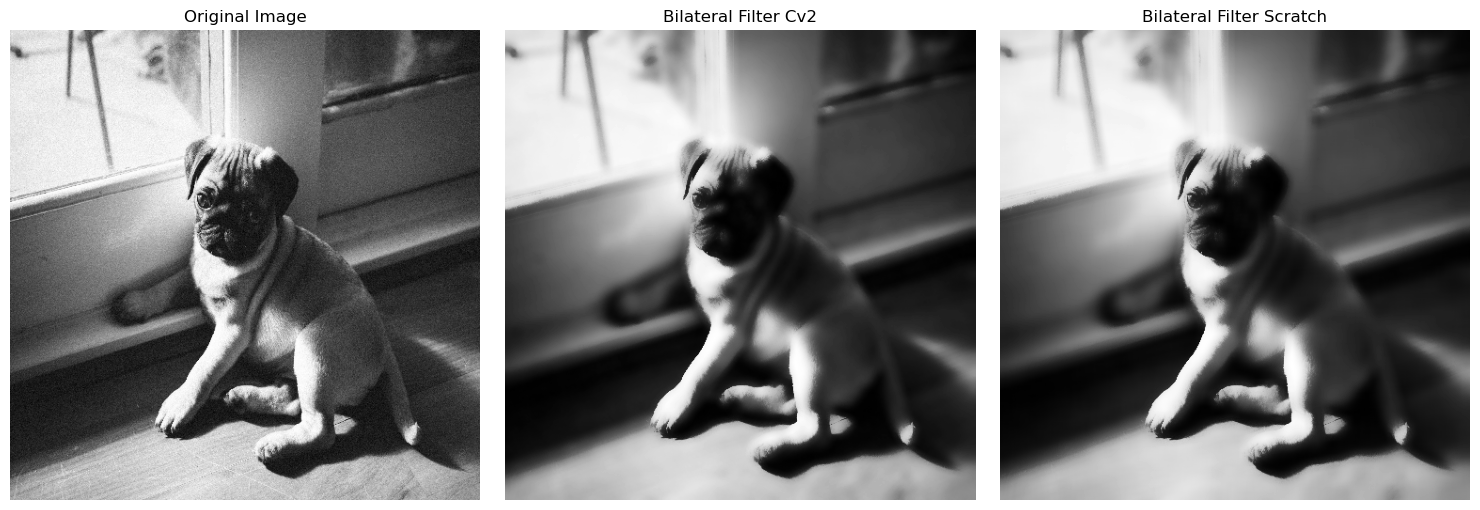

In [6]:
image_path = 'Image2.jpg'
L_image = cv2.imread(image_path)
L_image = cv2.resize(L_image, (500,500))
image = cv2.cvtColor(L_image, cv2.COLOR_BGR2GRAY)

print(f"Height: {image.shape[0]}, Width: {image.shape[1]}, Channels: {image.shape[2] if len(image.shape) > 2 else 1}")

filtered_image_OpenCV = cv2.bilateralFilter(image, 15, 75.0, 75.0)
filtered_image_Scratch = bilateral_filter_scratch(image, 15, 75.0, 75.0)
fig, axs = plt.subplots(1, 3, figsize=(15, 5))  

# Plot Original
axs[0].imshow(image, cmap='gray')
axs[0].set_title('Original Image')
axs[0].axis('off')

# Plot filtro do OpenCV
axs[1].imshow(filtered_image_OpenCV, cmap='gray')
axs[1].set_title('Bilateral Filter Cv2')
axs[1].axis('off')

# Plot filtro próprio
axs[2].imshow(filtered_image_Scratch, cmap='gray')
axs[2].set_title('Bilateral Filter Scratch')
axs[2].axis('off')

plt.tight_layout()
plt.show()

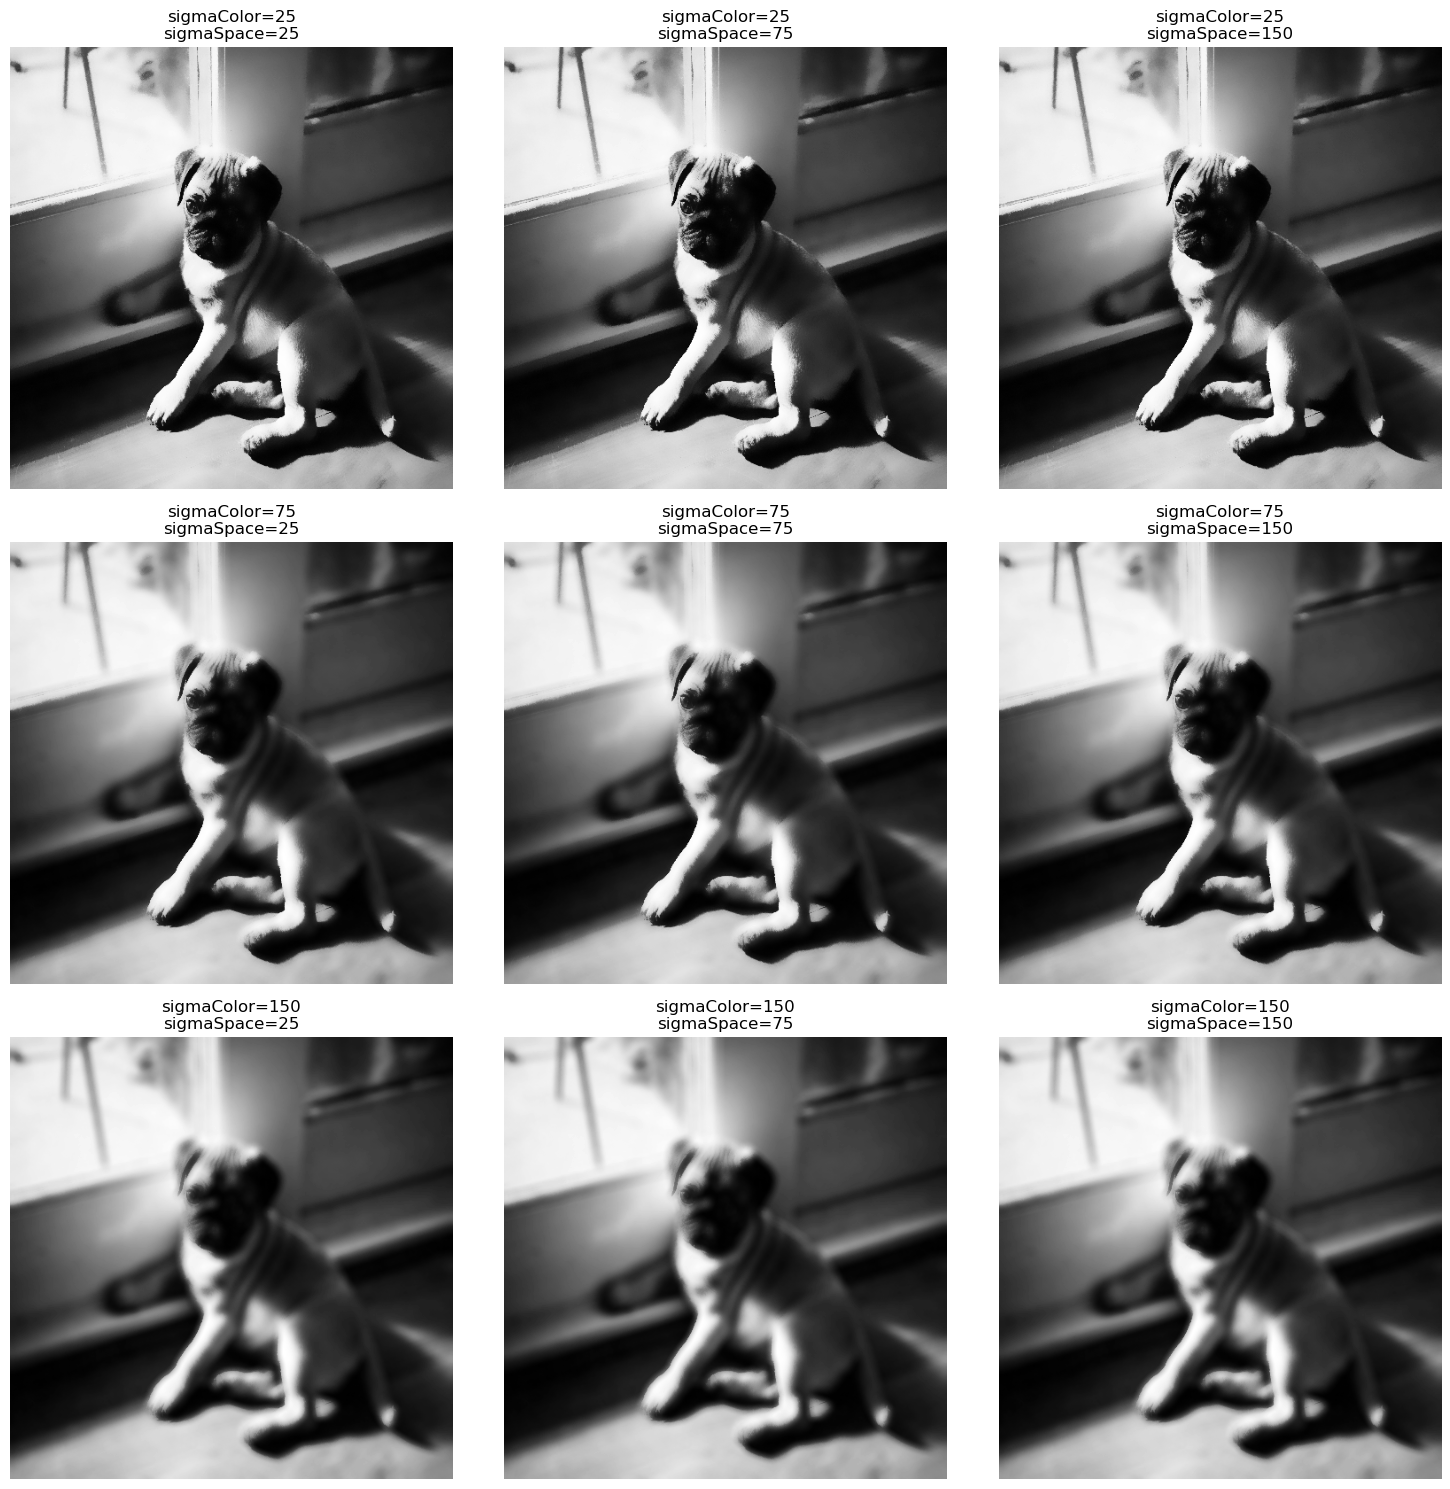

In [7]:
sigma_colors = [25, 75, 150]
sigma_spaces = [25, 75, 150]

fig, axs = plt.subplots(3, 3, figsize=(15, 15))

for i, sigma_color in enumerate(sigma_colors):
    for j, sigma_space in enumerate(sigma_spaces):
        filtered = cv2.bilateralFilter(image, d=15, sigmaColor=sigma_color, sigmaSpace=sigma_space)
        
        ax = axs[i, j]
        ax.imshow(filtered, cmap='gray')
        ax.set_title(f'sigmaColor={sigma_color}\nsigmaSpace={sigma_space}')
        ax.axis('off')

plt.tight_layout()
plt.show()

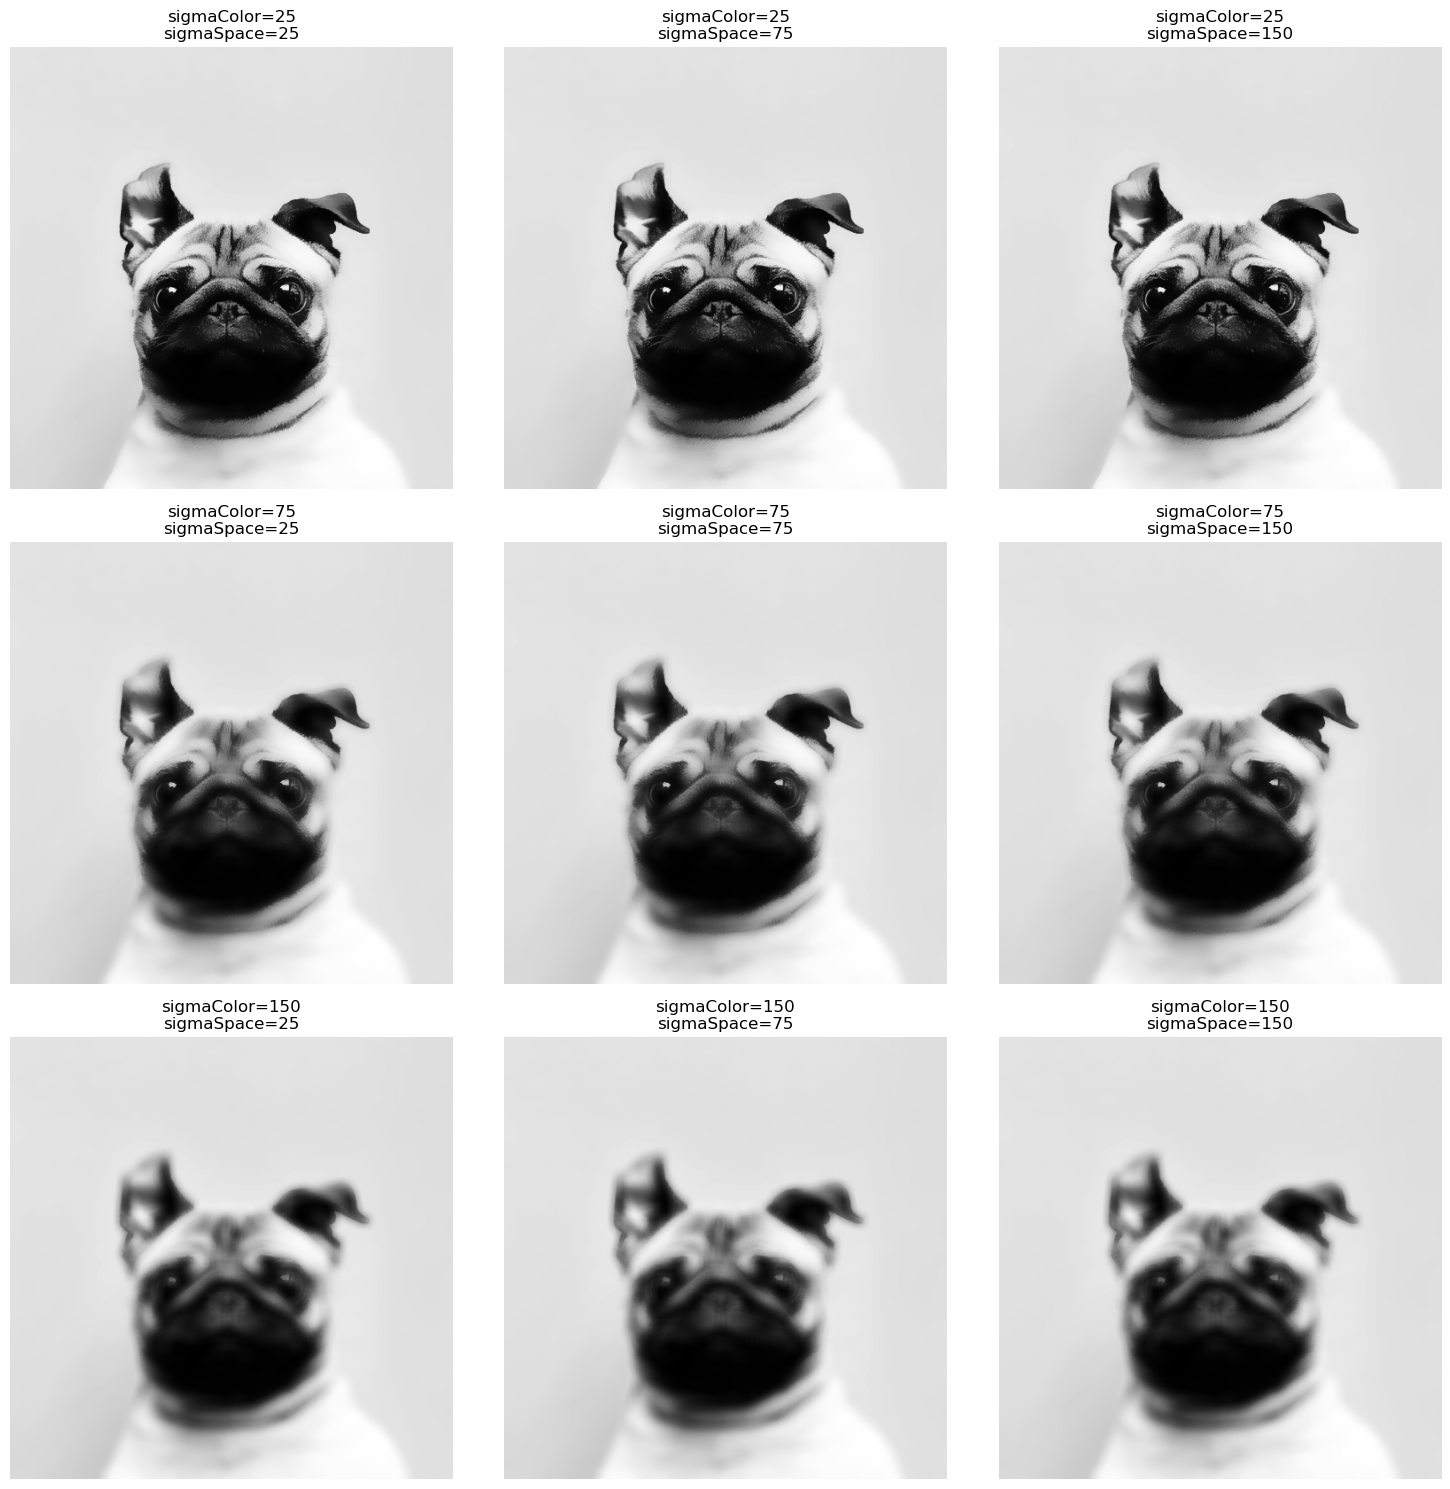

In [ ]:
fig, axs = plt.subplots(3, 3, figsize=(15, 15))

for i, sigma_color in enumerate(sigma_colors):
    for j, sigma_space in enumerate(sigma_spaces):
        filtered = bilateral_filter_scratch(image, 15, sigma_color, sigma_space)
        
        ax = axs[i, j]
        ax.imshow(filtered, cmap='gray')
        ax.set_title(f'sigmaColor={sigma_color}\nsigmaSpace={sigma_space}')
        ax.axis('off')

plt.tight_layout()
plt.show()

In [42]:
def compare_filters(image, d, sigma_values):
    results = {
        'bilateral': [],
        'gaussian': []
    }

    for sigma in sigma_values:
        # Bilateral filter (sigmaColor = sigmaSpace = sigma)
        filtered_bilat = bilateral_filter_scratch(image, d, sigma, sigma)
        mse_bilat = mean_squared_error(image, filtered_bilat)
        psnr_bilat = peak_signal_noise_ratio(image, filtered_bilat, data_range=255)
        ssim_bilat = structural_similarity(image, filtered_bilat, data_range=255)

        results['bilateral'].append({
            'sigma': sigma,
            'mse': mse_bilat,
            'psnr': psnr_bilat,
            'ssim': ssim_bilat
        })

        # Gaussian filter
        # ksize deve ser ímpar e igual a d
        filtered_gauss = cv2.GaussianBlur(image, (d, d), sigmaX=sigma)
        mse_gauss = mean_squared_error(image, filtered_gauss)
        psnr_gauss = peak_signal_noise_ratio(image, filtered_gauss, data_range=255)
        ssim_gauss = structural_similarity(image, filtered_gauss, data_range=255)

        results['gaussian'].append({
            'sigma': sigma,
            'mse': mse_gauss,
            'psnr': psnr_gauss,
            'ssim': ssim_gauss
        })

    return results
        

In [44]:
d = 15
sigma_values = [10, 25, 50, 75, 100, 150]

results = compare_filters(image, d, sigma_values)

# Mostrar resultados
print("Comparação Bilateral x Gaussian para diferentes valores de sigma (d=9):\n")

print("Bilateral Filter:")
for r in results['bilateral']:
    print(f"sigma={r['sigma']:>5} | MSE={r['mse']:.2f} | PSNR={r['psnr']:.2f} | SSIM={r['ssim']:.4f}")

print("\nGaussian Filter:")
for r in results['gaussian']:
    print(f"sigma={r['sigma']:>5} | MSE={r['mse']:.2f} | PSNR={r['psnr']:.2f} | SSIM={r['ssim']:.4f}")



Comparação Bilateral x Gaussian para diferentes valores de sigma (d=9):

Bilateral Filter:
sigma=   10 | MSE=3.26 | PSNR=43.00 | SSIM=0.9830
sigma=   25 | MSE=15.97 | PSNR=36.10 | SSIM=0.9568
sigma=   50 | MSE=45.61 | PSNR=31.54 | SSIM=0.9239
sigma=   75 | MSE=77.86 | PSNR=29.22 | SSIM=0.9003
sigma=  100 | MSE=106.59 | PSNR=27.85 | SSIM=0.8837
sigma=  150 | MSE=143.56 | PSNR=26.56 | SSIM=0.8656

Gaussian Filter:
sigma=   10 | MSE=180.75 | PSNR=25.56 | SSIM=0.8497
sigma=   25 | MSE=189.21 | PSNR=25.36 | SSIM=0.8461
sigma=   50 | MSE=190.18 | PSNR=25.34 | SSIM=0.8457
sigma=   75 | MSE=190.18 | PSNR=25.34 | SSIM=0.8457
sigma=  100 | MSE=190.18 | PSNR=25.34 | SSIM=0.8457
sigma=  150 | MSE=190.18 | PSNR=25.34 | SSIM=0.8457


para d = 9

Bilateral Filter:
sigma=   10 | MSE=3.16 | PSNR=43.13 | SSIM=0.9832
sigma=   25 | MSE=14.34 | PSNR=36.57 | SSIM=0.9588
sigma=   50 | MSE=35.60 | PSNR=32.62 | SSIM=0.9317
sigma=   75 | MSE=53.95 | PSNR=30.81 | SSIM=0.9159
sigma=  100 | MSE=68.17 | PSNR=29.79 | SSIM=0.9063
sigma=  150 | MSE=85.33 | PSNR=28.82 | SSIM=0.8965

Gaussian Filter:
sigma=   10 | MSE=104.33 | PSNR=27.95 | SSIM=0.8874
sigma=   25 | MSE=106.56 | PSNR=27.85 | SSIM=0.8858
sigma=   50 | MSE=106.56 | PSNR=27.85 | SSIM=0.8858
sigma=   75 | MSE=106.56 | PSNR=27.85 | SSIM=0.8858
sigma=  100 | MSE=106.56 | PSNR=27.85 | SSIM=0.8858
sigma=  150 | MSE=106.56 | PSNR=27.85 | SSIM=0.8858